# Brain Stroke Classification with Decision Tree

This notebook is rewritten to align closely with Lab 3 requirements on **Decision Tree Modeling and Improvement**.

Key ideas retained from the previous team notebook:
- Preserve the original exploratory data analysis direction.
- Reuse observations around `age`, `avg_glucose_level`, `bmi`, and class imbalance.
- Reorganize the workflow for report submission: **preprocessing -> baseline tree -> tree analysis -> improvements -> comparison**.

Main objectives:
1. Train a **baseline decision tree**.
2. Analyze tree structure according to parts **b, c** of the lab.
3. Evaluate additional improvement strategies for parts **d, e** in the report.


## Step 1. Import libraries and global configuration

Notes:
- `DecisionTreeClassifier` is the core model for this lab.
- `plot_tree` and `export_text` help visualize and explain split rules.
- `random_state=42` is used for reproducibility.


In [1]:
import random
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree

warnings.filterwarnings("ignore")

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42
DATA_PATH = Path("brain_stroke.csv")
RESULTS_DIR = Path("results")
IMAGES_DIR = Path("img")

np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

RESULTS_DIR.mkdir(exist_ok=True)
IMAGES_DIR.mkdir(exist_ok=True)

print(f"Data file exists: {DATA_PATH.exists()}")

Data file exists: True


## Step 2. Load and describe the dataset

Goals of this step:
- Verify dataset loading works correctly.
- Check number of rows, columns, and data types.
- Prepare dataset description material for the report.


In [2]:
df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
print("Columns:", list(df.columns))
print("\nFirst 5 rows:")
display(df.head())


Dataset shape: (4981, 11)
Columns: ['gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status', 'stroke']

First 5 rows:


,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
2,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
3,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
4,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1


In [3]:
print("Data type information:")
df.info()

print("\nDescriptive statistics for numeric columns:")
display(df.describe().T)


Data type information:
<class 'pandas.DataFrame'>
RangeIndex: 4981 entries, 0 to 4980
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             4981 non-null   str    
 1   age                4981 non-null   float64
 2   hypertension       4981 non-null   int64  
 3   heart_disease      4981 non-null   int64  
 4   ever_married       4981 non-null   str    
 5   work_type          4981 non-null   str    
 6   Residence_type     4981 non-null   str    
 7   avg_glucose_level  4981 non-null   float64
 8   bmi                4981 non-null   float64
 9   smoking_status     4981 non-null   str    
 10  stroke             4981 non-null   int64  
dtypes: float64(3), int64(3), str(5)
memory usage: 428.2 KB

Descriptive statistics for numeric columns:


,count,mean,std,min,25%,50%,75%,max
age,4981.0,43.419859,22.662755,0.08,25.00,45.00,61.00,82.00
hypertension,4981.0,0.096165,0.294848,0.00,0.00,0.00,0.00,1.00
heart_disease,4981.0,0.055210,0.228412,0.00,0.00,0.00,0.00,1.00
avg_glucose_level,4981.0,105.943562,45.075373,55.12,77.23,91.85,113.86,271.74
bmi,4981.0,28.498173,6.790464,14.00,23.70,28.10,32.60,48.90
stroke,4981.0,0.049789,0.217531,0.00,0.00,0.00,0.00,1.00


## Step 3. Data quality checks

The previous notebook already checked missing values and duplicates.
This notebook keeps that check, but presents it in a cleaner report-ready format.


In [4]:
missing_summary = df.isna().sum().sort_values(ascending=False)
duplicate_count = df.duplicated().sum()
class_distribution = df["stroke"].value_counts().sort_index()
class_ratio = (df["stroke"].value_counts(normalize=True).sort_index() * 100).round(2)

print("Missing values by column:")
display(missing_summary.to_frame(name="missing_count"))

print(f"Duplicate rows: {duplicate_count}")

print("\nTarget distribution for `stroke`:")
summary_df = pd.DataFrame({
    "count": class_distribution,
    "ratio_percent": class_ratio,
})
display(summary_df)


Missing values by column:


,missing_count
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,0
smoking_status,0


Duplicate rows: 0

Target distribution for `stroke`:


,count,ratio_percent
stroke,,
0,4733,95.02
1,248,4.98


## Step 4. Quick EDA aligned with the original notebook

Findings from the previous analysis:
- `age` shows a meaningful relationship with stroke.
- The dataset is **strongly imbalanced**.
- `avg_glucose_level` and `bmi` are also important features.

This section keeps the main visuals for report-ready exploratory analysis.


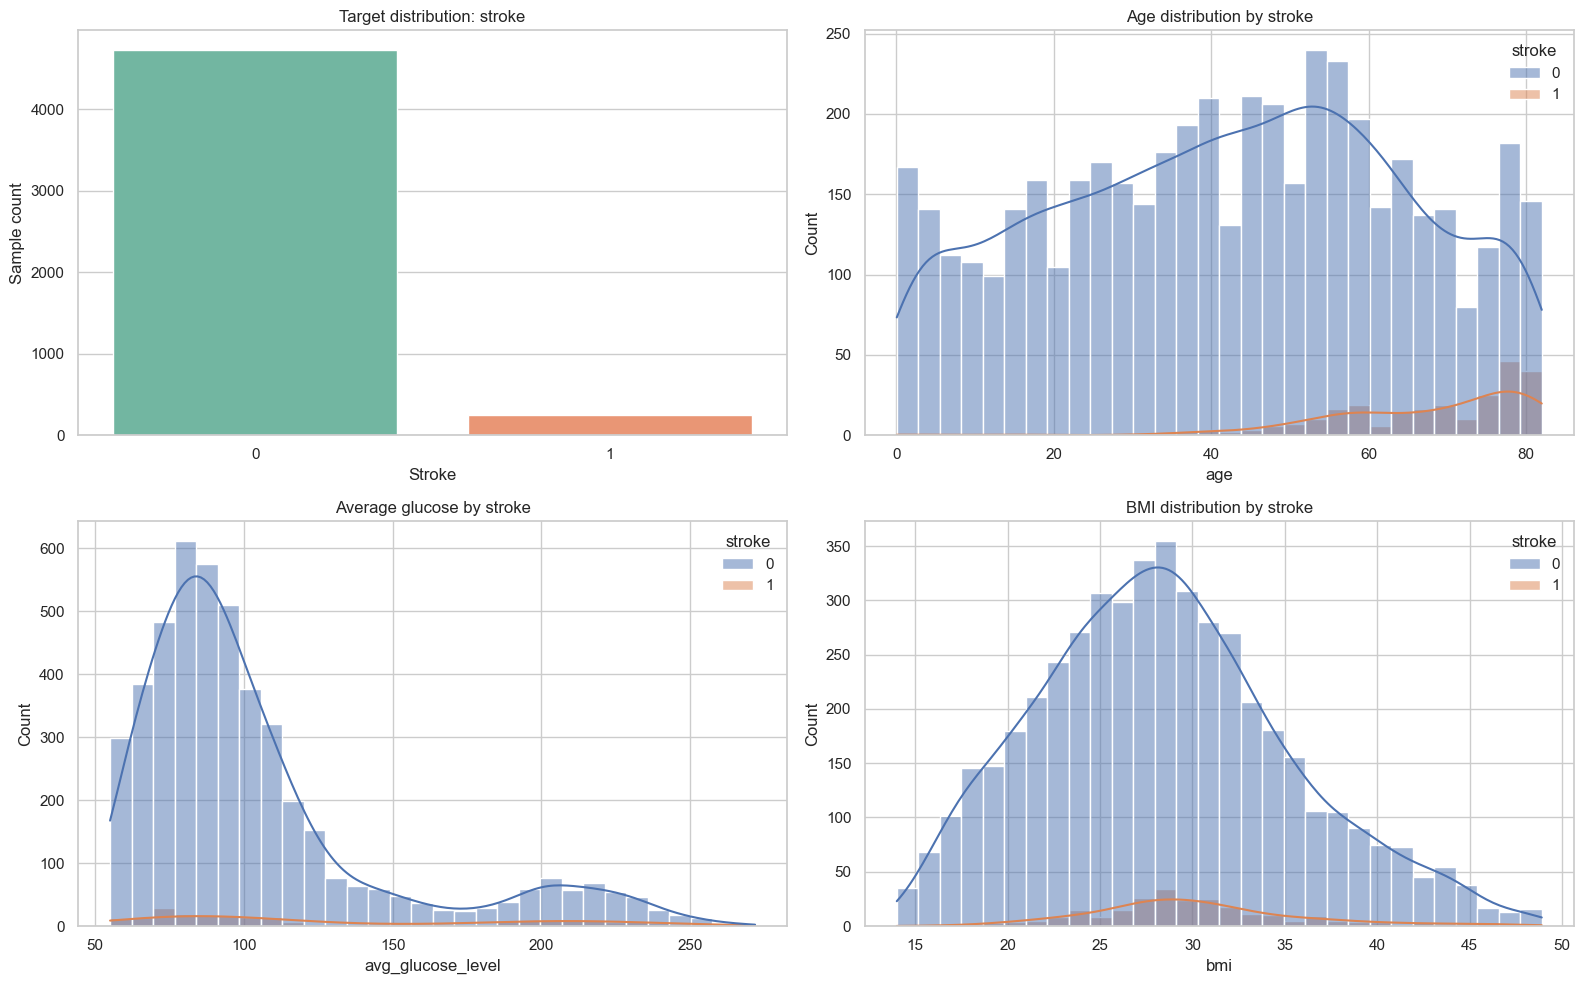

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Plot 1: class count distribution.
sns.countplot(data=df, x="stroke", palette="Set2", ax=axes[0, 0])
axes[0, 0].set_title("Target distribution: stroke")
axes[0, 0].set_xlabel("Stroke")
axes[0, 0].set_ylabel("Sample count")

# Plot 2: age distribution by stroke status.
sns.histplot(data=df, x="age", hue="stroke", bins=30, kde=True, ax=axes[0, 1])
axes[0, 1].set_title("Age distribution by stroke")

# Plot 3: average glucose distribution by stroke status.
sns.histplot(data=df, x="avg_glucose_level", hue="stroke", bins=30, kde=True, ax=axes[1, 0])
axes[1, 0].set_title("Average glucose by stroke")

# Plot 4: BMI distribution by stroke status.
sns.histplot(data=df, x="bmi", hue="stroke", bins=30, kde=True, ax=axes[1, 1])
axes[1, 1].set_title("BMI distribution by stroke")

plt.tight_layout()
plt.show()


## Step 5. Data preprocessing for the baseline Decision Tree

Preprocessing decisions in the baseline setup:
- Split train/test first to avoid data leakage.
- Use `ColumnTransformer` + `Pipeline` for consistent feature-wise processing.
- Numeric features: `SimpleImputer(strategy="mean")`.
- Categorical features: `SimpleImputer(strategy="most_frequent")` + `OneHotEncoder(handle_unknown="ignore")`.
- **No feature scaling** because Decision Trees are not scale-sensitive like Logistic Regression or SVM.
- **No SMOTE in baseline** so the baseline remains a faithful reference model.


In [6]:
df_model = df.copy()

# Split target first to avoid data leakage.
X_raw = df_model.drop(columns=["stroke"])
y = df_model["stroke"]

# Identify column groups for preprocessing pipeline.
categorical_columns = X_raw.select_dtypes(include="object").columns.tolist()
numeric_columns = [col for col in X_raw.columns if col not in categorical_columns]
print("Categorical columns to encode:", categorical_columns)

# Split train/test first, then fit preprocessing only on training data.
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
    )

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="mean")),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_columns),
        ("cat", categorical_transformer, categorical_columns),
    ]
)

X_train = preprocessor.fit_transform(X_train_raw)
X_test = preprocessor.transform(X_test_raw)

feature_names = preprocessor.get_feature_names_out()
X_train = pd.DataFrame(X_train, columns=feature_names, index=X_train_raw.index)
X_test = pd.DataFrame(X_test, columns=feature_names, index=X_test_raw.index)

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("Stroke rate in train:", round(y_train.mean() * 100, 2), "%")
print("Stroke rate in test :", round(y_test.mean() * 100, 2), "%")

Categorical columns to encode: ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
X_train shape: (3984, 19)
X_test shape : (997, 19)
Stroke rate in train: 4.97 %
Stroke rate in test : 5.02 %


## Step 6. Helper functions for model evaluation

Separating reusable helpers improves readability:
- `evaluate_tree_model`: train and return all required metrics.
- `show_confusion_matrix`: visualize confusion matrices.
- `summarize_overfitting`: provide quick overfitting interpretation.


In [7]:
def evaluate_tree_model(model_name, model, X_train, X_test, y_train, y_test):
    # Train the model on the training set.
    model.fit(X_train, y_train)

    # Predict class labels and probabilities on the test set.
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    # Collect all report metrics in a single dictionary.
    result = {
        "model_name": model_name,
        "model": model,
        "y_pred": y_pred,
        "y_prob": y_prob,
        "confusion_matrix": cm,
        "train_accuracy": accuracy_score(y_train, model.predict(X_train)),
        "accuracy": accuracy_score(y_test, y_pred),
        "error_rate": 1 - accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1_score": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_prob),
        "false_negative_rate": fn / (fn + tp) if (fn + tp) > 0 else 0.0,
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
        "depth": model.get_depth(),
        "n_leaves": model.get_n_leaves(),
    }
    return result


def show_confusion_matrix(cm, title, save_path=None):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Stroke", "Stroke"])
    disp.plot(cmap="Blues", values_format="d")
    plt.title(title)
    plt.grid(False)
    if save_path is not None:
        plt.tight_layout()
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()


def summarize_overfitting(train_acc, test_acc):
    gap = train_acc - test_acc
    if gap >= 0.10:
        return f"Train accuracy is higher than test by {gap:.4f} -> strong overfitting signal."
    if gap >= 0.05:
        return f"Train/test gap is {gap:.4f} -> mild overfitting signal."
    return f"Train/test gap is {gap:.4f} -> overfitting is not a major concern."


def result_to_frame(result):
    return pd.DataFrame(
        {
            "Metric": [
                "Train Accuracy",
                "Accuracy",
                "Error Rate",
                "Precision",
                "Recall",
                "F1-Score",
                "ROC-AUC",
                "False Negative Rate",
                "Tree Depth",
                "Number of Leaves",
            ],
            "Value": [
                result["train_accuracy"],
                result["accuracy"],
                result["error_rate"],
                result["precision"],
                result["recall"],
                result["f1_score"],
                result["roc_auc"],
                result["false_negative_rate"],
                result["depth"],
                result["n_leaves"],
            ],
        }
    )

## Step 7. Train the baseline Decision Tree

This is the reference model:
- Default `DecisionTreeClassifier`.
- No `class_weight` tuning.
- No pruning constraints.
- No criterion change.


In [8]:
baseline_model = DecisionTreeClassifier(random_state=RANDOM_STATE)
baseline_result = evaluate_tree_model(
    "Baseline Decision Tree",
    baseline_model,
    X_train,
    X_test,
    y_train,
    y_test,
)

print("=== BASELINE MODEL RESULTS ===")
display(result_to_frame(baseline_result))

print("Classification report:")
print(classification_report(y_test, baseline_result["y_pred"], zero_division=0))


=== BASELINE MODEL RESULTS ===


,Metric,Value
0,Train Accuracy,1.000000
1,Accuracy,0.901705
2,Error Rate,0.098295
3,Precision,0.136364
4,Recall,0.180000
5,F1-Score,0.155172
6,ROC-AUC,0.559905
7,False Negative Rate,0.820000
8,Tree Depth,22.000000
9,Number of Leaves,299.000000


Classification report:
              precision    recall  f1-score   support

           0       0.96      0.94      0.95       947
           1       0.14      0.18      0.16        50

    accuracy                           0.90       997
   macro avg       0.55      0.56      0.55       997
weighted avg       0.91      0.90      0.91       997



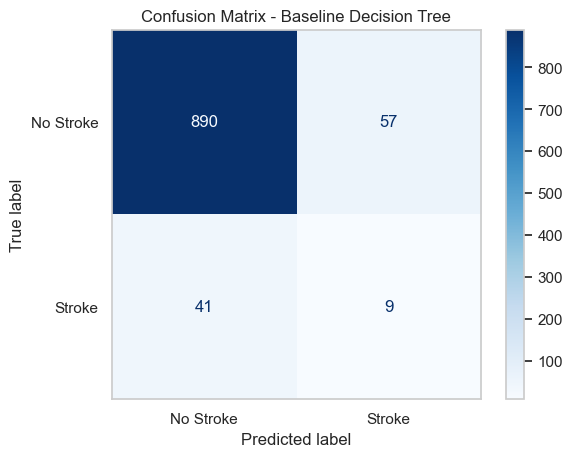

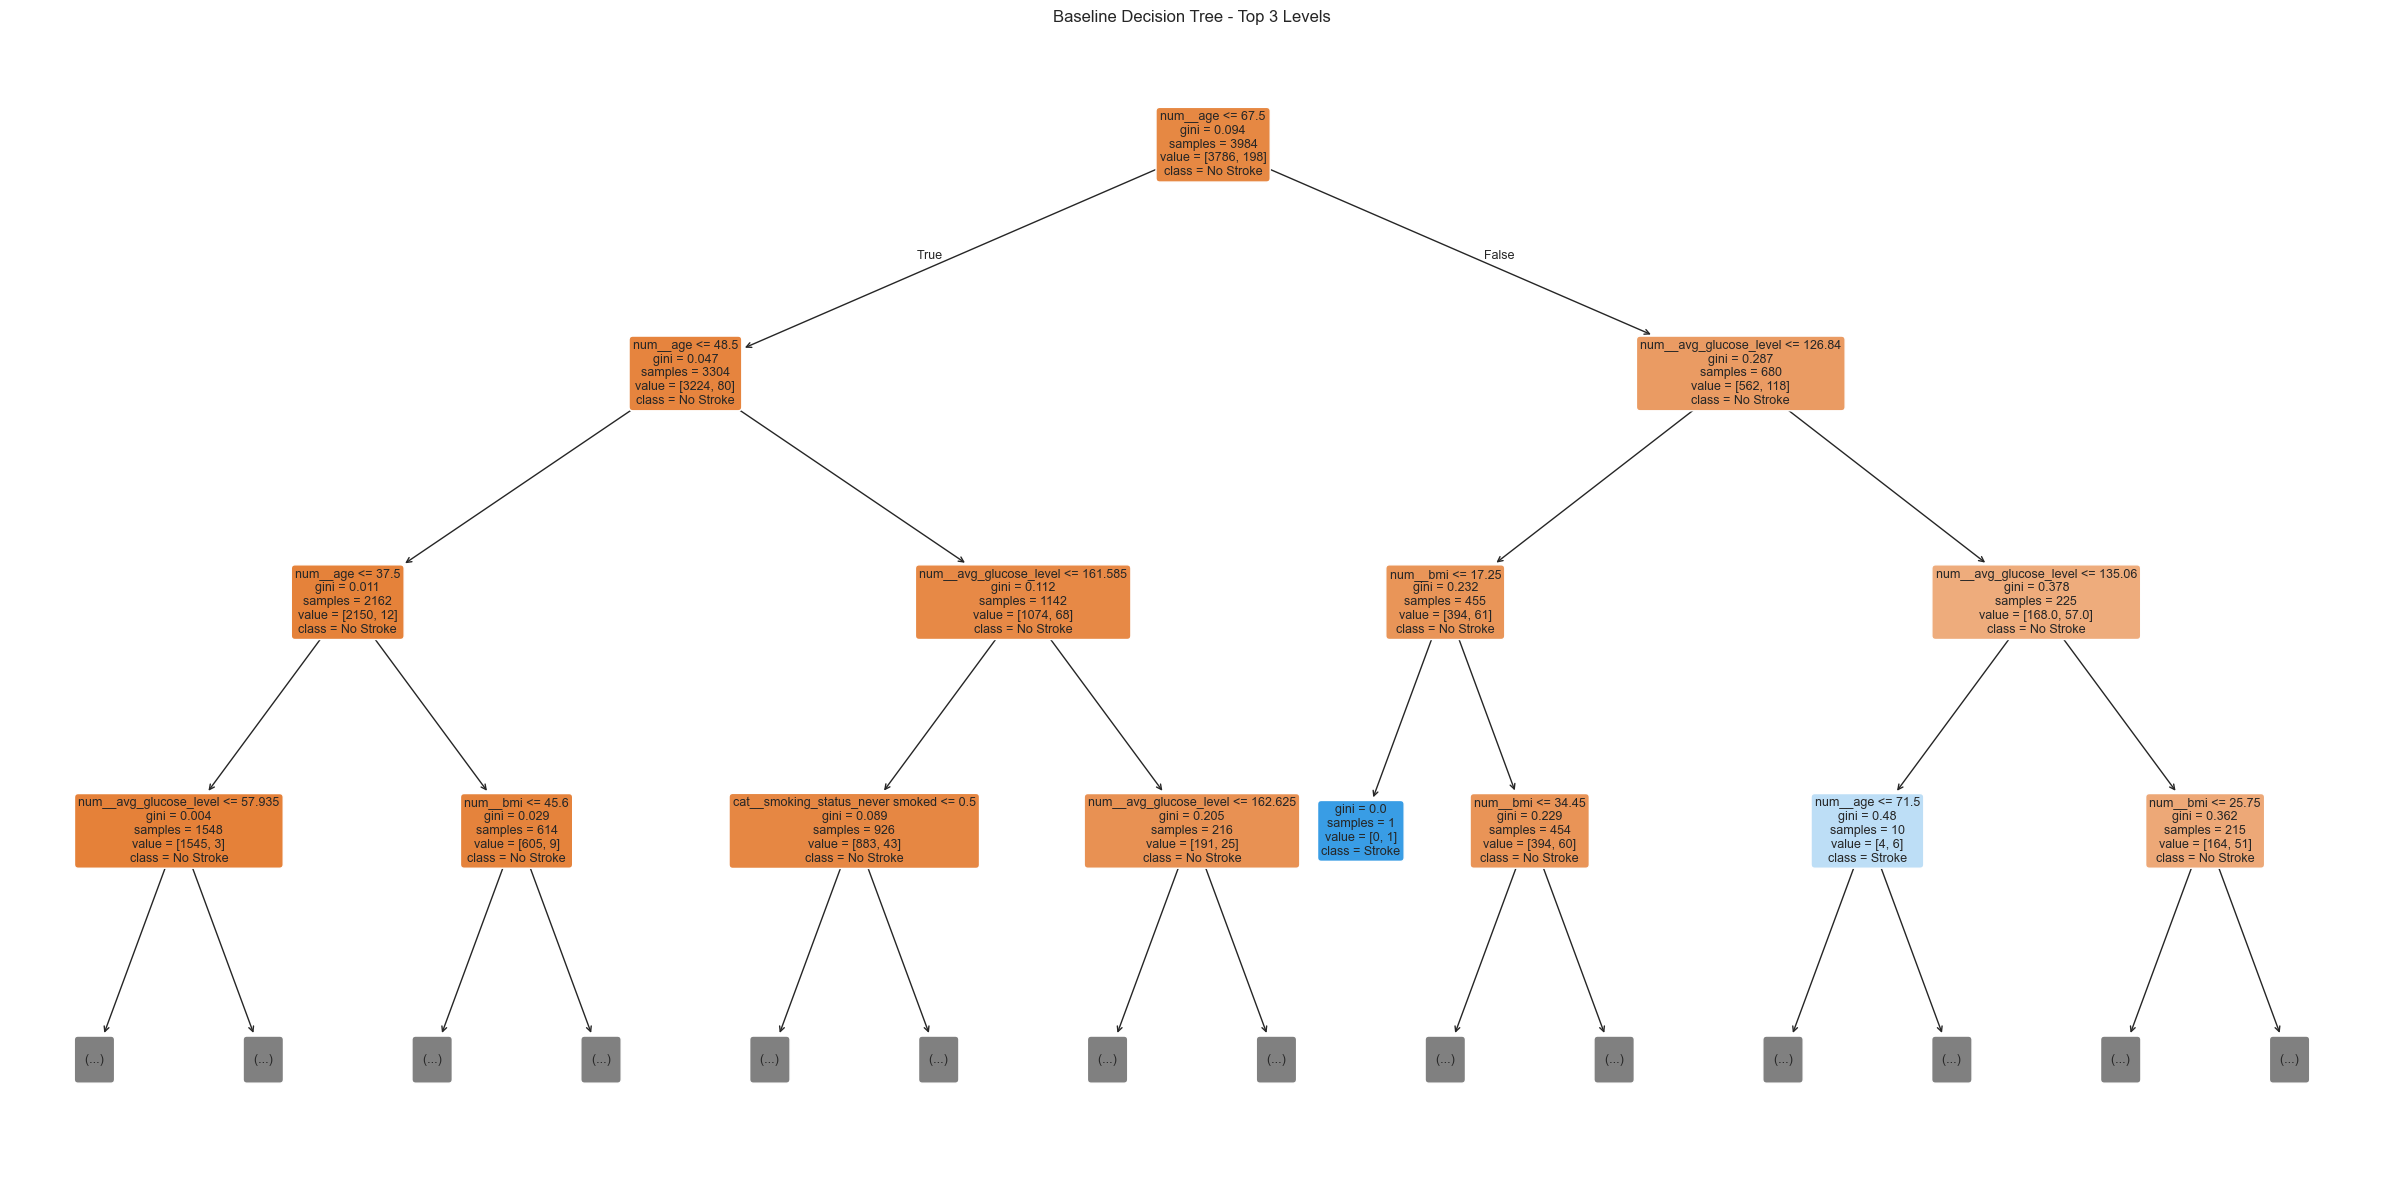

In [9]:
# Plot confusion matrix to inspect where the baseline model fails.
show_confusion_matrix(
    baseline_result["confusion_matrix"],
    "Confusion Matrix - Baseline Decision Tree"
 )

# Plot the top 3 tree levels for report visuals and interpretation.
plt.figure(figsize=(24, 12))
plot_tree(
    baseline_result["model"],
    feature_names=X_train.columns,
    class_names=["No Stroke", "Stroke"],
    filled=True,
    rounded=True,
    fontsize=9,
    max_depth=3,
)
plt.title("Baseline Decision Tree - Top 3 Levels")
plt.tight_layout()
plt.savefig(IMAGES_DIR / "baseline_tree_top3.png", dpi=200, bbox_inches="tight")
plt.show()

## Step 8. Analyze the trained decision tree (core of part c)

This section directly answers:
- Is the tree deep or shallow?
- Which features are most important?
- What are the main split rules?
- Is there evidence of overfitting?


In [10]:
baseline_tree = baseline_result["model"]
root_feature_index = baseline_tree.tree_.feature[0]
root_threshold = baseline_tree.tree_.threshold[0]
root_feature_name = X_train.columns[root_feature_index]

feature_importance = (
    pd.Series(baseline_tree.feature_importances_, index=X_train.columns)
    .sort_values(ascending=False)
    .head(10)
)

print("=== BASELINE TREE ANALYSIS ===")
print(f"Tree depth: {baseline_result['depth']}")
print(f"Number of leaves: {baseline_result['n_leaves']}")
print(f"Root split: {root_feature_name} <= {root_threshold:.2f}")
print(summarize_overfitting(baseline_result["train_accuracy"], baseline_result["accuracy"]))
print(f"False Negative Rate: {baseline_result['false_negative_rate']:.4f}")

print("\nTop 10 important features:")
display(feature_importance.to_frame(name="importance"))

print("\nTruncated split rules up to depth 4:")
baseline_rules = export_text(baseline_tree, feature_names=list(X_train.columns), max_depth=4)
print(baseline_rules)

(RESULTS_DIR / "baseline_rules.txt").write_text(baseline_rules, encoding="utf-8")
feature_importance.to_frame(name="importance").to_csv(
    RESULTS_DIR / "feature_importance.csv",
    index=True
 )

=== BASELINE TREE ANALYSIS ===
Tree depth: 22
Number of leaves: 299
Root split: num__age <= 67.50
Train/test gap is 0.0983 -> mild overfitting signal.
False Negative Rate: 0.8200

Top 10 important features:


,importance
num__avg_glucose_level,0.319918
num__age,0.197906
num__bmi,0.183371
cat__Residence_type_Urban,0.029955
cat__Residence_type_Rural,0.029429
cat__gender_Male,0.028271
cat__work_type_Self-employed,0.027573
cat__gender_Female,0.027346
cat__smoking_status_smokes,0.024916
cat__smoking_status_never smoked,0.020132



Truncated split rules up to depth 4:
|--- num__age <= 67.50
|   |--- num__age <= 48.50
|   |   |--- num__age <= 37.50
|   |   |   |--- num__avg_glucose_level <= 57.93
|   |   |   |   |--- num__avg_glucose_level <= 57.92
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- num__avg_glucose_level >  57.92
|   |   |   |   |   |--- class: 1
|   |   |   |--- num__avg_glucose_level >  57.93
|   |   |   |   |--- num__age <= 1.36
|   |   |   |   |   |--- truncated branch of depth 3
|   |   |   |   |--- num__age >  1.36
|   |   |   |   |   |--- truncated branch of depth 4
|   |   |--- num__age >  37.50
|   |   |   |--- num__bmi <= 45.60
|   |   |   |   |--- cat__smoking_status_formerly smoked <= 0.50
|   |   |   |   |   |--- truncated branch of depth 6
|   |   |   |   |--- cat__smoking_status_formerly smoked >  0.50
|   |   |   |   |   |--- truncated branch of depth 7
|   |   |   |--- num__bmi >  45.60
|   |   |   |   |--- cat__gender_Male <= 0.50
|   |   |   |   |   |--- class: 0
|   |   | 

In [11]:
print("=== REPORT-READY OBSERVATIONS ===")

top3 = feature_importance.head(3).index.tolist()

print(f"1. The baseline tree is very deep ({baseline_result['depth']} levels) with {baseline_result['n_leaves']} leaves.")
print("2. Train accuracy is very high while test accuracy is lower, indicating possible overfitting.")
print(f"3. The most important features in the current tree are: {', '.join(top3)}.")
print("4. Early tree splits frequently involve age, glucose, and BMI.")
print("5. Under heavy class imbalance, high accuracy can still miss many stroke-positive cases.")


=== REPORT-READY OBSERVATIONS ===
1. The baseline tree is very deep (22 levels) with 299 leaves.
2. Train accuracy is very high while test accuracy is lower, indicating possible overfitting.
3. The most important features in the current tree are: num__avg_glucose_level, num__age, num__bmi.
4. Early tree splits frequently involve age, glucose, and BMI.
5. Under heavy class imbalance, high accuracy can still miss many stroke-positive cases.


## Step 9. Improve the Decision Tree

Improvement strategies are separated clearly for lab alignment and comparison:

- **Improvement 1 - Class Weight**: force stronger attention to the minority class.
- **Improvement 2 - Pruning**: constrain depth and leaf size to reduce overfitting.
- **Improvement 3 - Entropy**: switch split criterion to `entropy`.
- **Final Selected Model (combined)**: `class_weight + entropy + pruning` as a merged configuration.


In [12]:
model_candidates = {
    "Baseline": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Improvement 1 - Class Weight": DecisionTreeClassifier(
        random_state=RANDOM_STATE,
        class_weight="balanced",
    ),
    "Improvement 2 - Pruning": DecisionTreeClassifier(
        random_state=RANDOM_STATE,
        max_depth=5,
        min_samples_leaf=10,
    ),
    "Improvement 3 - Entropy": DecisionTreeClassifier(
        random_state=RANDOM_STATE,
        criterion="entropy",
    ),
    "Final Selected Model": DecisionTreeClassifier(
        random_state=RANDOM_STATE,
        class_weight="balanced",
        criterion="entropy",
        max_depth=5,
        min_samples_leaf=10,
    ),
}

all_results = {}

for model_name, model in model_candidates.items():
    all_results[model_name] = evaluate_tree_model(
        model_name,
        model,
        X_train,
        X_test,
        y_train,
        y_test,
    )

comparison_rows = []
for model_name, result in all_results.items():
    comparison_rows.append(
        {
            "Model": model_name,
            "Train Accuracy": result["train_accuracy"],
            "Accuracy": result["accuracy"],
            "Error Rate": result["error_rate"],
            "Precision": result["precision"],
            "Recall": result["recall"],
            "F1": result["f1_score"],
            "ROC-AUC": result["roc_auc"],
            "FNR": result["false_negative_rate"],
            "Depth": result["depth"],
            "Leaves": result["n_leaves"],
        }
    )

comparison_df = pd.DataFrame(comparison_rows).sort_values(
    by=["F1", "Recall", "ROC-AUC"],
    ascending=False
).reset_index(drop=True)

display(comparison_df.round(4))

,Model,Train Accuracy,Accuracy,Error Rate,Precision,Recall,F1,ROC-AUC,FNR,Depth,Leaves
0,Final Selected Model,0.7882,0.7763,0.2237,0.1381,0.66,0.2284,0.7735,0.34,5,23
1,Improvement 1 - Class Weight,1.0000,0.9258,0.0742,0.1842,0.14,0.1591,0.5536,0.86,29,349
2,Baseline,1.0000,0.9017,0.0983,0.1364,0.18,0.1552,0.5599,0.82,22,299
3,Improvement 3 - Entropy,1.0000,0.9168,0.0832,0.0769,0.06,0.0674,0.5110,0.94,31,269
4,Improvement 2 - Pruning,0.9508,0.9468,0.0532,0.0000,0.00,0.0000,0.7812,1.00,5,26


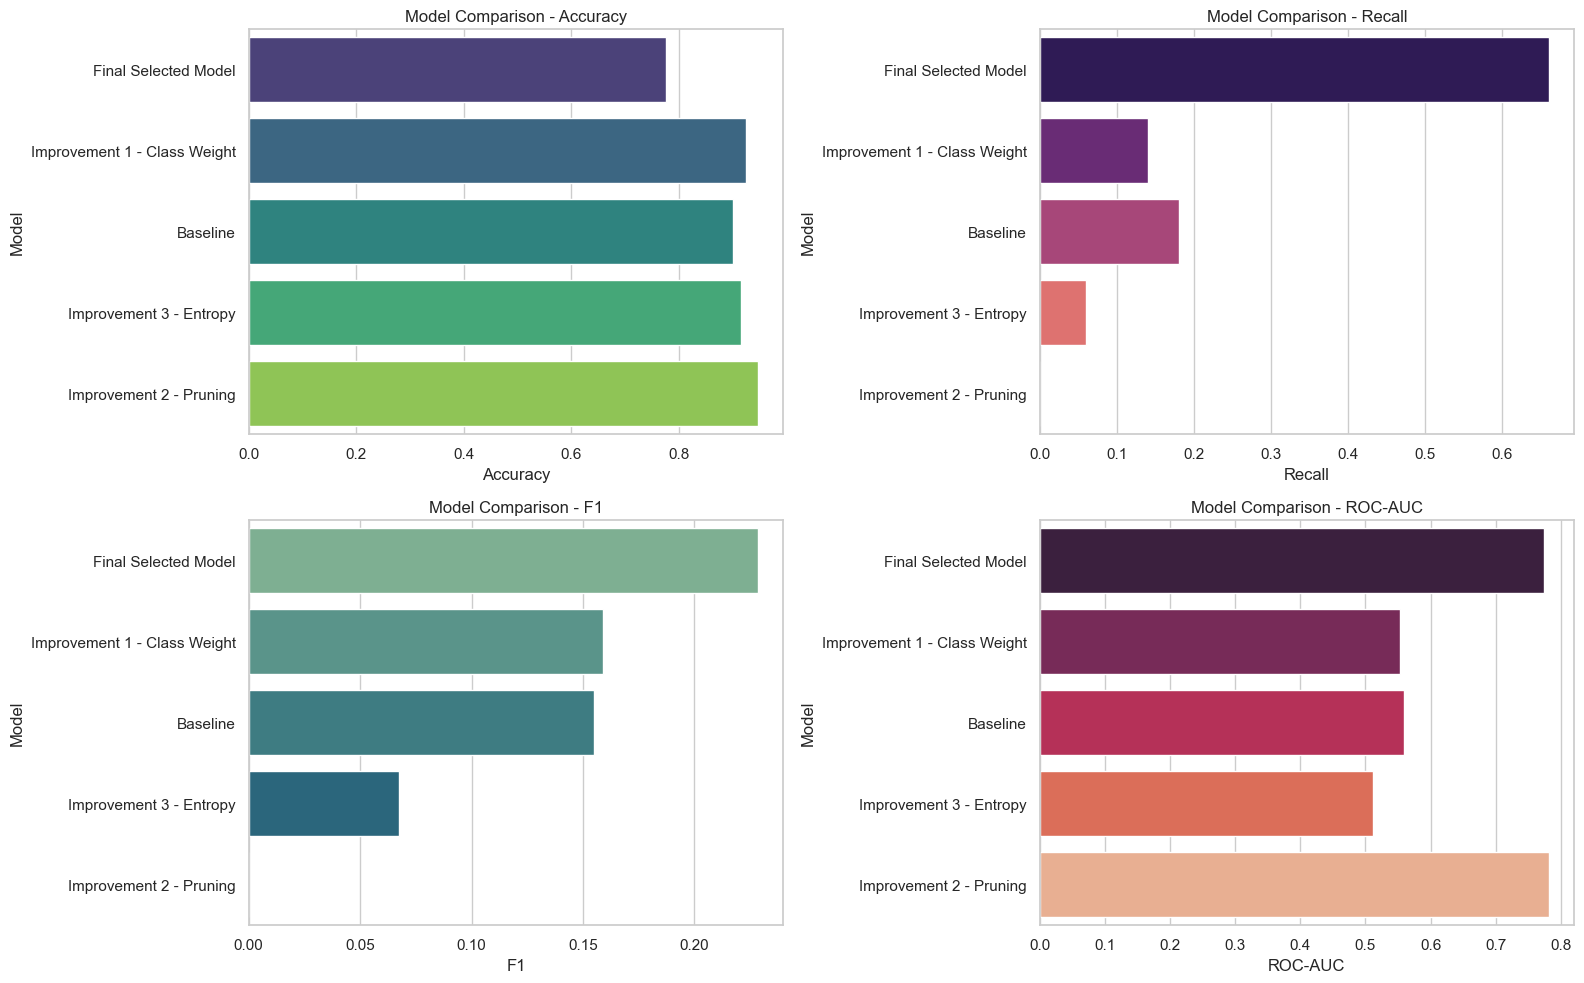

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

sns.barplot(data=comparison_df, x="Accuracy", y="Model", palette="viridis", ax=axes[0, 0])
axes[0, 0].set_title("Model Comparison - Accuracy")

sns.barplot(data=comparison_df, x="Recall", y="Model", palette="magma", ax=axes[0, 1])
axes[0, 1].set_title("Model Comparison - Recall")

sns.barplot(data=comparison_df, x="F1", y="Model", palette="crest", ax=axes[1, 0])
axes[1, 0].set_title("Model Comparison - F1")

sns.barplot(data=comparison_df, x="ROC-AUC", y="Model", palette="rocket", ax=axes[1, 1])
axes[1, 1].set_title("Model Comparison - ROC-AUC")

plt.tight_layout()
plt.savefig(IMAGES_DIR / "comparison_metrics.png", dpi=200, bbox_inches="tight")
plt.show()

In [14]:
best_accuracy_model = comparison_df.sort_values(by="Accuracy", ascending=False).iloc[0]["Model"]
best_f1_model = comparison_df.sort_values(by="F1", ascending=False).iloc[0]["Model"]
best_recall_model = comparison_df.sort_values(by="Recall", ascending=False).iloc[0]["Model"]
selected_model_name = "Final Selected Model"

print("=== CONCLUSIONS FROM MODEL COMPARISON ===")
print(f"Highest Accuracy model: {best_accuracy_model}")
print(f"Highest F1-Score model: {best_f1_model}")
print(f"Highest Recall model: {best_recall_model}")
print(f"=> Final selected model for reporting: {selected_model_name}")
print("\nSuggested report notes:")
print("- For stroke prediction, prioritize Recall/F1 to reduce missed positive cases.")
print("- Accuracy should still be reported, but not used as the only criterion.")
print("- Lower FNR (False Negative Rate) is better in medical screening contexts.")

=== CONCLUSIONS FROM MODEL COMPARISON ===
Highest Accuracy model: Improvement 2 - Pruning
Highest F1-Score model: Final Selected Model
Highest Recall model: Final Selected Model
=> Final selected model for reporting: Final Selected Model

Suggested report notes:
- For stroke prediction, prioritize Recall/F1 to reduce missed positive cases.
- Accuracy should still be reported, but not used as the only criterion.
- Lower FNR (False Negative Rate) is better in medical screening contexts.


## Step 9.5. Final experiment summary, CV, and artifact export

This cell generates complete artifacts for report submission and presentation:

- Build final summary table and save `results/metrics_summary.csv`.
- Save classification reports for baseline and selected model.
- Save baseline/final confusion matrices as image files.
- Run cross-validation on the final model to reduce one-split dependency.
- Print environment information for reproducibility.


,Model,Selected,Train Accuracy,Accuracy,Error Rate,Precision,Recall,F1,ROC-AUC,FNR,Depth,Leaves
0,Final Selected Model,Yes,0.7882,0.7763,0.2237,0.1381,0.66,0.2284,0.7735,0.34,5,23
1,Improvement 1 - Class Weight,No,1.0000,0.9258,0.0742,0.1842,0.14,0.1591,0.5536,0.86,29,349
2,Baseline,No,1.0000,0.9017,0.0983,0.1364,0.18,0.1552,0.5599,0.82,22,299
3,Improvement 3 - Entropy,No,1.0000,0.9168,0.0832,0.0769,0.06,0.0674,0.5110,0.94,31,269
4,Improvement 2 - Pruning,No,0.9508,0.9468,0.0532,0.0000,0.00,0.0000,0.7812,1.00,5,26


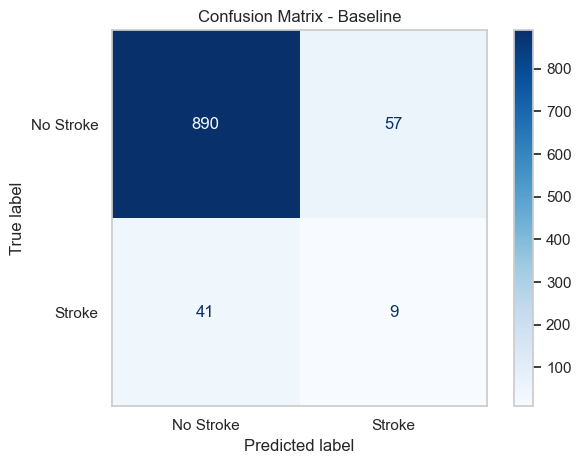

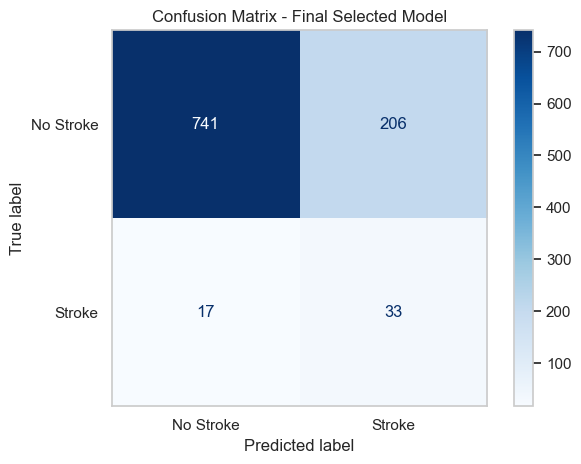

=== CROSS-VALIDATION (5-FOLD) - FINAL MODEL ===
Mean CV Accuracy: 0.7105 +/- 0.0442
Mean CV Recall  : 0.7458 +/- 0.0734
Mean CV F1      : 0.2056 +/- 0.0140
Mean CV ROC-AUC : 0.7833 +/- 0.0217


,Metric,Mean,Std
0,accuracy,0.7105,0.0442
1,recall,0.7458,0.0734
2,f1,0.2056,0.0140
3,roc_auc,0.7833,0.0217



=== REPRODUCIBILITY INFO ===
Python version : 3.14.0
numpy version  : 2.4.4
pandas version : 3.0.2
scikit-learn   : 1.8.0
matplotlib     : 3.10.8
seaborn        : 0.13.2
random_state   : 42

Artifacts have been saved to results/ and img/.


In [15]:
# 1) Build and save the final summary table.
final_summary_df = comparison_df.copy()
final_summary_df.insert(1, "Selected", final_summary_df["Model"].eq(selected_model_name).map({True: "Yes", False: "No"}))
final_summary_df = final_summary_df[[
    "Model", "Selected", "Train Accuracy", "Accuracy", "Error Rate",
    "Precision", "Recall", "F1", "ROC-AUC", "FNR", "Depth", "Leaves"
]]
display(final_summary_df.round(4))
final_summary_df.round(6).to_csv(RESULTS_DIR / "metrics_summary.csv", index=False)

# 2) Save classification reports for baseline and selected model.
baseline_report = classification_report(y_test, all_results["Baseline"]["y_pred"], zero_division=0)
final_report = classification_report(y_test, all_results[selected_model_name]["y_pred"], zero_division=0)

classification_reports_text = (
    "=== Baseline Decision Tree ===\n" + baseline_report + "\n\n"
    + f"=== {selected_model_name} ===\n" + final_report
)
(RESULTS_DIR / "classification_reports.txt").write_text(classification_reports_text, encoding="utf-8")
(RESULTS_DIR / "classification_report.txt").write_text(classification_reports_text, encoding="utf-8")

# 3) Save confusion matrices for baseline and final model.
show_confusion_matrix(
    all_results["Baseline"]["confusion_matrix"],
    "Confusion Matrix - Baseline",
    save_path=IMAGES_DIR / "confusion_baseline.png",
)
show_confusion_matrix(
    all_results[selected_model_name]["confusion_matrix"],
    f"Confusion Matrix - {selected_model_name}",
    save_path=IMAGES_DIR / "confusion_final.png",
)

# 4) Export selected model rules.
final_rules = export_text(
    all_results[selected_model_name]["model"],
    feature_names=list(X_train.columns),
    max_depth=6,
)
(RESULTS_DIR / "final_model_rules.txt").write_text(final_rules, encoding="utf-8")

# 5) Cross-validation for selected model stability (leakage-safe setup).
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

preprocessor_cv = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[("imputer", SimpleImputer(strategy="mean"))]), numeric_columns),
        (
            "cat",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", OneHotEncoder(handle_unknown="ignore")),
                ]
            ),
            categorical_columns,
        ),
    ]
)

cv_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor_cv),
        (
            "model",
            DecisionTreeClassifier(
                random_state=RANDOM_STATE,
                class_weight="balanced",
                criterion="entropy",
                max_depth=5,
                min_samples_leaf=10,
            ),
        ),
    ]
)

cv_scores = cross_validate(
    cv_pipeline,
    X_raw,
    y,
    cv=cv,
    scoring={
        "accuracy": "accuracy",
        "recall": "recall",
        "f1": "f1",
        "roc_auc": "roc_auc",
    },
    n_jobs=-1,
)

print("=== CROSS-VALIDATION (5-FOLD) - FINAL MODEL ===")
print(f"Mean CV Accuracy: {cv_scores['test_accuracy'].mean():.4f} +/- {cv_scores['test_accuracy'].std():.4f}")
print(f"Mean CV Recall  : {cv_scores['test_recall'].mean():.4f} +/- {cv_scores['test_recall'].std():.4f}")
print(f"Mean CV F1      : {cv_scores['test_f1'].mean():.4f} +/- {cv_scores['test_f1'].std():.4f}")
print(f"Mean CV ROC-AUC : {cv_scores['test_roc_auc'].mean():.4f} +/- {cv_scores['test_roc_auc'].std():.4f}")

cv_summary_df = pd.DataFrame(
    [
        {"Metric": "accuracy", "Mean": cv_scores["test_accuracy"].mean(), "Std": cv_scores["test_accuracy"].std()},
        {"Metric": "recall", "Mean": cv_scores["test_recall"].mean(), "Std": cv_scores["test_recall"].std()},
        {"Metric": "f1", "Mean": cv_scores["test_f1"].mean(), "Std": cv_scores["test_f1"].std()},
        {"Metric": "roc_auc", "Mean": cv_scores["test_roc_auc"].mean(), "Std": cv_scores["test_roc_auc"].std()},
    ]
)
display(cv_summary_df.round(4))
cv_summary_df.to_csv(RESULTS_DIR / "final_model_cv_summary.csv", index=False)

# 6) Print environment details for reproducibility.
print("\n=== REPRODUCIBILITY INFO ===")
print(f"Python version : {sys.version.split()[0]}")
print(f"numpy version  : {np.__version__}")
print(f"pandas version : {pd.__version__}")
print(f"scikit-learn   : {sklearn.__version__}")
print(f"matplotlib     : {plt.matplotlib.__version__}")
print(f"seaborn        : {sns.__version__}")
print(f"random_state   : {RANDOM_STATE}")

environment_info_text = "\n".join([
    f"Python version: {sys.version.split()[0]}",
    f"numpy version: {np.__version__}",
    f"pandas version: {pd.__version__}",
    f"scikit-learn version: {sklearn.__version__}",
    f"matplotlib version: {plt.matplotlib.__version__}",
    f"seaborn version: {sns.__version__}",
    f"random_state: {RANDOM_STATE}",
])
(RESULTS_DIR / "environment_info.txt").write_text(environment_info_text, encoding="utf-8")

print("\nArtifacts have been saved to results/ and img/.")

## Step 10. Visualize the selected model tree against baseline

This cell provides a compact tree figure for the report and makes it easier to discuss the **final selected model** structure relative to the baseline.


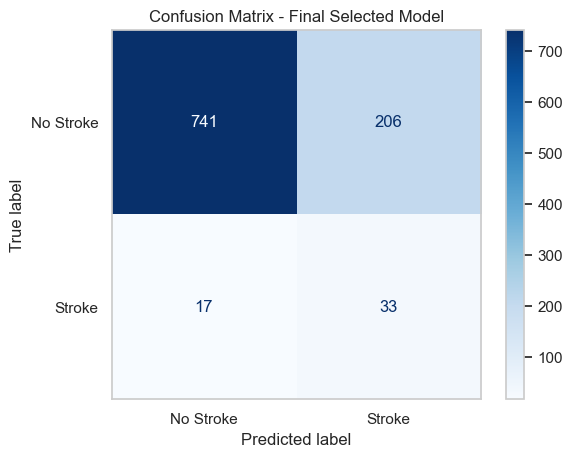

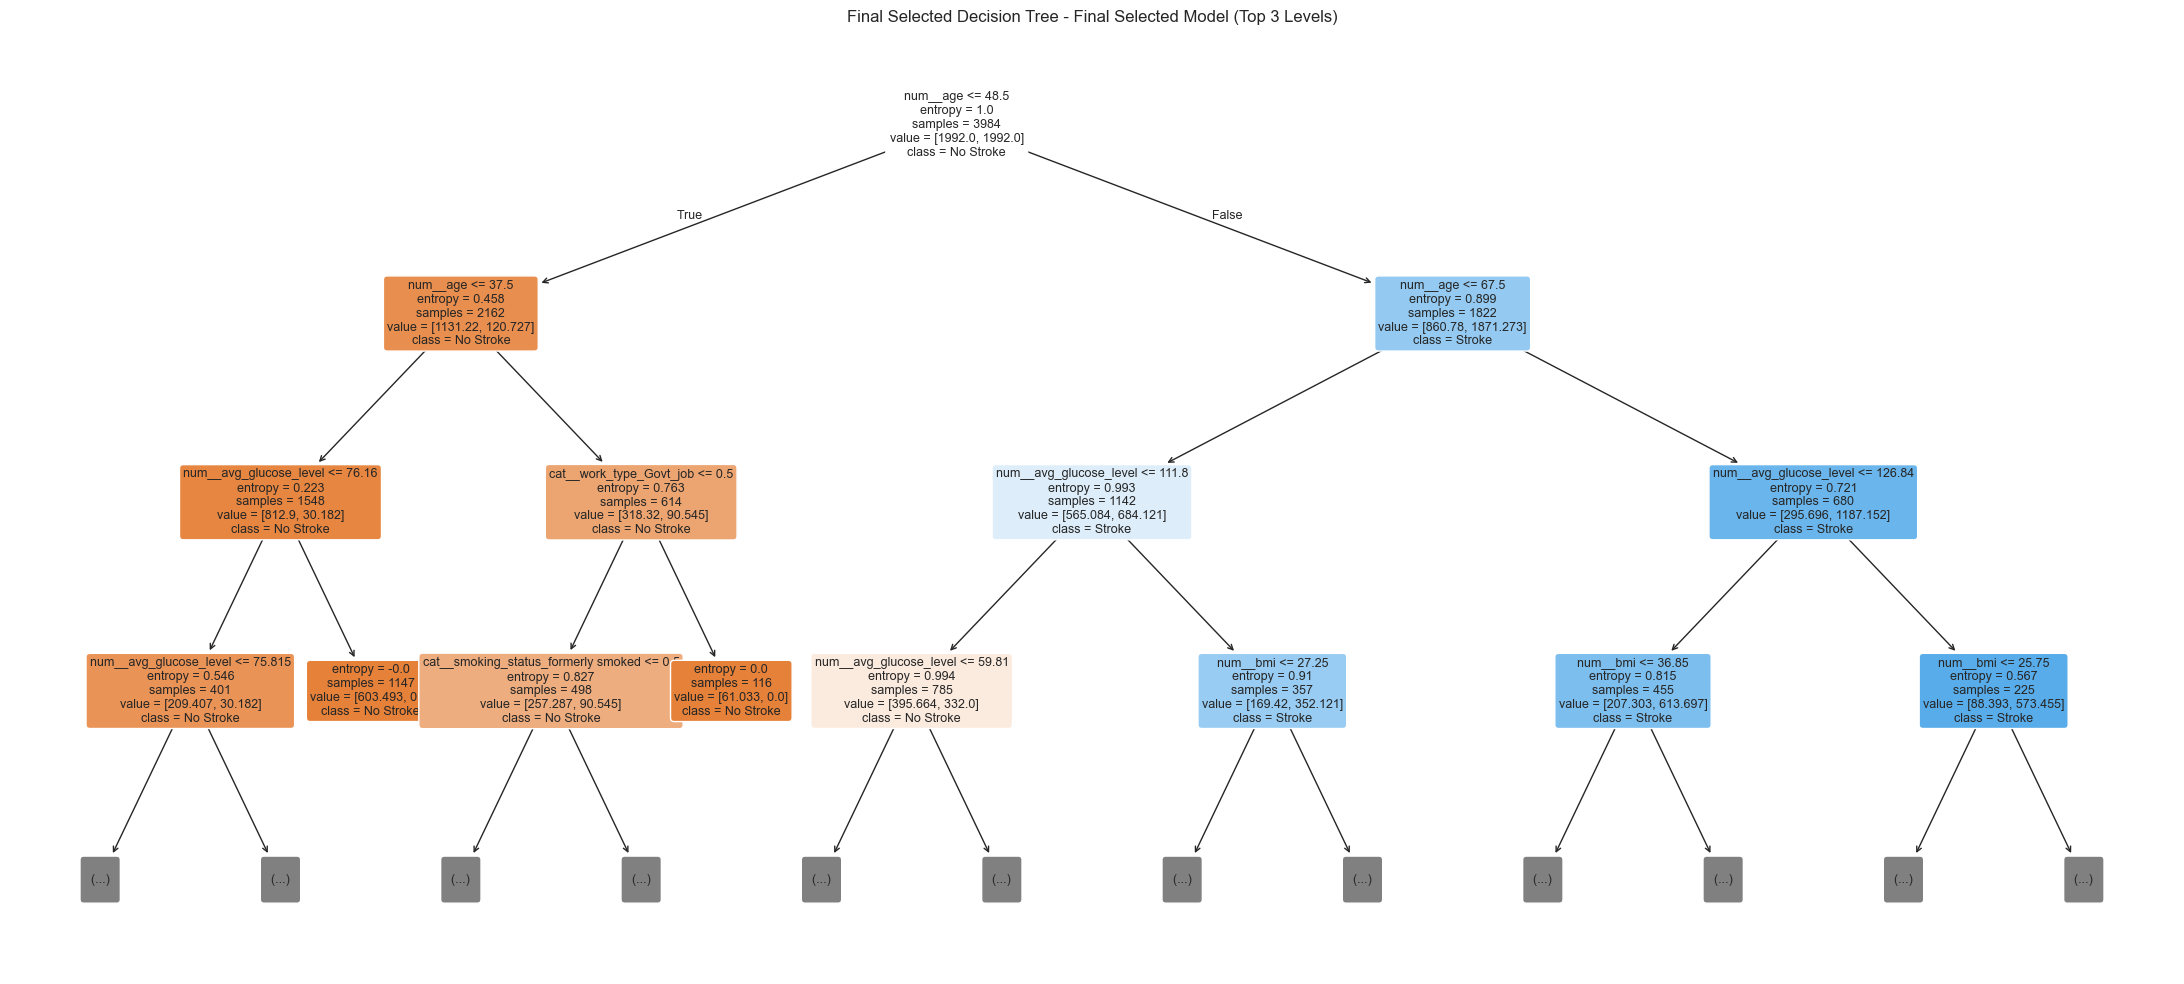

In [16]:
final_tree_result = all_results[selected_model_name]

show_confusion_matrix(
    final_tree_result["confusion_matrix"],
    f"Confusion Matrix - {selected_model_name}"
)

plt.figure(figsize=(22, 10))
plot_tree(
    final_tree_result["model"],
    feature_names=X_train.columns,
    class_names=["No Stroke", "Stroke"],
    filled=True,
    rounded=True,
    fontsize=9,
    max_depth=3,
)
plt.title(f"Final Selected Decision Tree - {selected_model_name} (Top 3 Levels)")
plt.tight_layout()
plt.savefig(IMAGES_DIR / "final_tree_top3.png", dpi=200, bbox_inches="tight")
plt.show()

## Suggested final notebook conclusion

Possible key points for write-up:
- The baseline tree often achieves decent accuracy but tends to be deep and can overfit.
- Under class imbalance, improved configurations may lower accuracy while increasing recall or F1.
- The combined model (`class_weight + entropy + pruning`) often gives a more compact tree with better balance than baseline.
- For stroke prediction, evaluate both **overall accuracy** and **positive-case detection capability**.
